<a href="https://colab.research.google.com/github/colabhd/visualizar-dados/blob/main/Tipos_de_visualiza%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualização de dados

Fazer uma visualização de dados, ou seja, pegarmos dados dispersos e confusos e transformar em algo visual, pode parecer uma tarefa complexa, entretanto com o auxilio de algumas perguntas, podemos definir o tipo que era ser utilizado.


# Biblioteca

Para nos auxiliar na criação de visualização temos ferramentas como o matplotlib e o seaborn, cada um com uma particularidade e com uso próprio

## Matplotlib


O **Matplotlib** é uma biblioteca mais tradicional do Python usada para gerar visualizações de dados, gráficos 2D e plotagens(criação de gráfico). Sendo uma das ferramentas mais comuns, na hora de fazer gráficos.

In [ ]:
# Instalação para usar o matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime

## Seaborn


Para explorarmos o máximo do **matplotlib**, podemos explorar suas extensões e outros pacotes de visualizações, permitindo que os usuários criem qualquer tipo de gráfico, sendo uma dessas bibliotecas, o *seaborn*.

In [ ]:
# Instalação do seaborn pelo PyPI
!pip install seaborn
import seaborn as sns

In [ ]:
#Instalação do seaborn pelo conda
# conda install seaborn

## Ploty
O Ploty é uma biblioteca de código aberto que permite a geração de mais de 40 tipos de gráfico diferentes, como mapas 3D e diagramas de sankey (que serão abordados posteriormente). Sua principal função é sua interatividade e sua facilidade de uso.


In [ ]:
#Instalçãp do plotly
!pip install plotly
import plotly.express as px

# Tipos de visualização de dados

## Distribuição

Quando surge a necessidade de entender como os dados numéricos estão espalhados, concentrados ou agrupados, identificando a média, amplitude e outliers (valores discrepantes). Elas são essenciais para análise estatística, controle de qualidade, e quando você precisa visualizar a forma ("formato") dos dados, como normalidade ou assimetria, e não apenas o total ou a tendência.

O primeiro passo para testarmos os diferentes gráfico existentes é selecionarmo os dados que serão utilizados.

In [ ]:
dados_banco = {
    "Servico": (
        ["Caixa_Eletronico"] * 15 +
        ["Atendimento_Gerente"] * 15 +
        ["Abertura_Conta"] * 15
    ),

    "Tempo_Espera": [
        # Caixa_Eletronico: Valores muito próximos (Baixa dispersão)
        4, 5, 5, 6, 6, 6, 7, 7, 7, 7, 8, 8, 8, 9, 10,

        # Atendimento_Gerente: Distribuição Simétrica (Média 30)
        15, 20, 22, 25, 28, 30, 30, 30, 30, 32, 35, 38, 40, 45, 50,

        # Abertura_Conta: Valores variados com Outliers (Valores extremos)
        10, 12, 15, 18, 20, 22, 25, 30, 35, 40, 45, 50, 85, 90, 110
    ]
}
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df = pd.DataFrame(dados_banco)

### Histograma
A função principal de um histograma é mostrar a distribuição da frequência de um conjunto de dados contínuos e/ou quantitativos. Diferente de um gráfico de barras, que compara categorias isoladas, o histograma agrupa os dados em intervalos (bins) para revelar o "comportamento" de uma variável.

No exemplo abaxo, temos a idade media de clientes. No eixo x, vemos os intervalos das variavéis e no eixo y percebemos a ocorrência de cada intervalo.

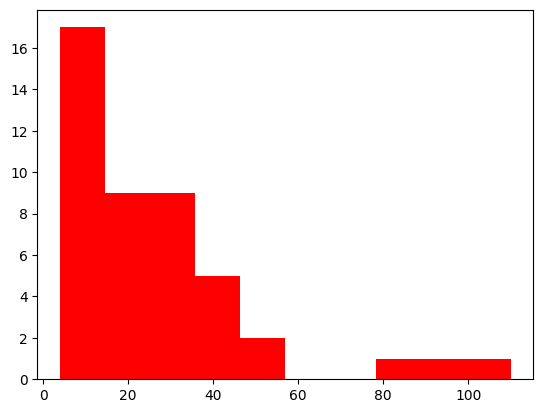

In [ ]:
plt.hist(df["Tempo_Espera"], color= "r")
plt.show()

### Densidade
Visualizam a distribuiçã de probabilidade de variavéis contínuas, suavizando histogramas para mostrar o formato de dados


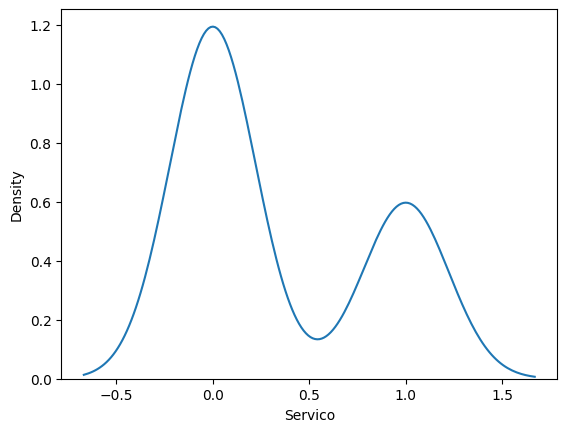

In [ ]:
sns.kdeplot(df['Servico'] == 'Atendimento_Gerente')
plt.show()

### Violino
O diagrama de violino serve para visualizar a distribuição de dados numéricos, combinando características de um box plot com a densidade de probabilidade dos dados. Ele é ideal para entender a forma da distribuição (simetria, multimodalidade) e ver onde os dados estão concentrados, indo além do que um box plot tradicional mostra

<Axes: xlabel='Servico', ylabel='Tempo_Espera'>

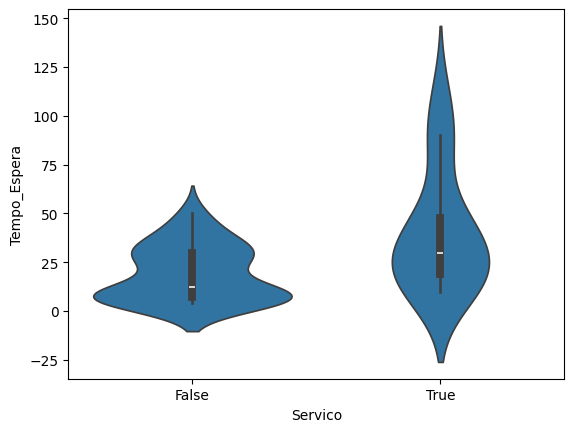

In [ ]:
sns.violinplot(x=df["Servico"] == 'Abertura_Conta', y=df["Tempo_Espera"])

## Correlação
Gráficos de correlação (ou diagramas de dispersão) servem para visualizar e analisar a relação entre duas variáveis numéricas, identificando se elas estão ligadas (correlação positiva ou negativa) ou se não há associação. Eles ajudam a detectar tendências, intensidade da relação e valores discrepantes (outliers).

In [ ]:
# Dados de ma cafeteria
dados_cafeteria = {
    "Mes": ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"],
    "Investimento_Marketing": [2, 2.5, 3, 3.2, 4, 4.5, 5, 5.5, 6, 7, 8, 10],
    "Vendas": [15, 18, 21, 20, 25, 28, 30, 32, 35, 40, 48, 60],
    "Tamanho_Loja_m2": [40, 40, 45, 45, 50, 50, 60, 60, 70, 70, 80, 100],
    "Regiao": ["Sul", "Sul", "Sul", "Norte", "Norte", "Norte", "Centro", "Centro", "Centro", "Oeste", "Oeste", "Oeste"]
}
df = pd.DataFrame(dados_cafeteria)

### Dispersão
O Gráfico de Dispersão é utilizado para analisar a relação entre duas variáveis quantitativas. Ele permite identificar rapidamente se existe uma correlação (positiva ou negativa) ou se os dados são independentes. Além disso, é uma ferramenta visual poderosa para detectar outliers (dados fora do padrão) que poderiam passar despercebidos em tabelas.

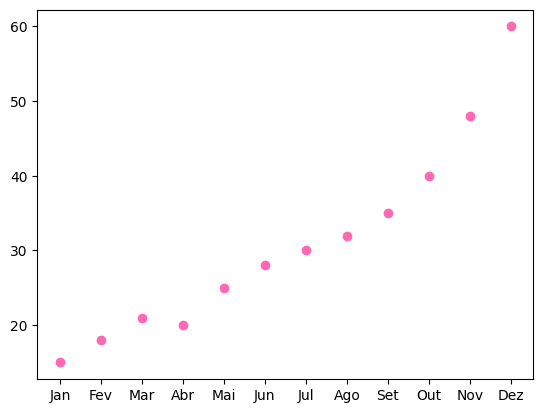

In [ ]:
plt.scatter(df['Mes'], df['Vendas'], color ="hotpink") # a função scatter ao invés de linhas cria pontos para a visualização
plt.show()                           # escolha da cor

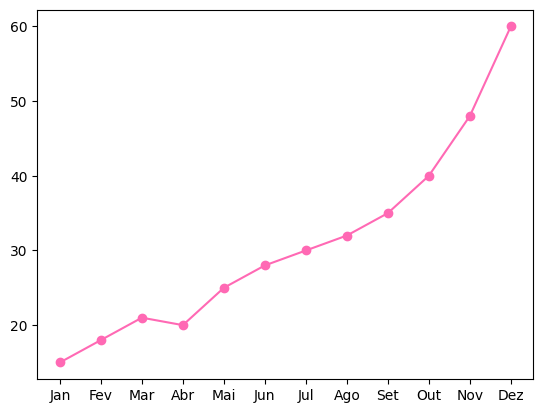

In [ ]:
# Disperão conectada
# Utiliza do gráfico de linha com adiciona de pontos
plt.plot(df['Mes'], df['Vendas'], linestyle="-", marker="o", color ="hotpink")
plt.show()                      #adiciona pontos em uma visualização de linha

## Ranking
Gráficos de ranking servem para ordenar e comparar categorias (como produtos, vendedores ou marcas) com base em valores quantitativos, facilitando a identificação rápida dos melhores e piores desempenhos. Eles transformam dados complexos em visuais claros, ajudando na tomada de decisão estratégica e na visualização de mudanças de posição ao longo do tempo

### Barra
Gráficos de barra são visualizações ideais para comparar quantidades entre diferentes grupos ou categorias, diferenciando rapidamente valores máximos, mínimos e médios. Eles utilizam retângulos (horizontais ou verticais) onde o comprimento representa o valor, sendo essenciais para dados nominais ou ordinais com um número limitado de categorias.

#### Verticais
Utiliza a função `bar()` com duas variavéis para agirem como o x e y do gráfico



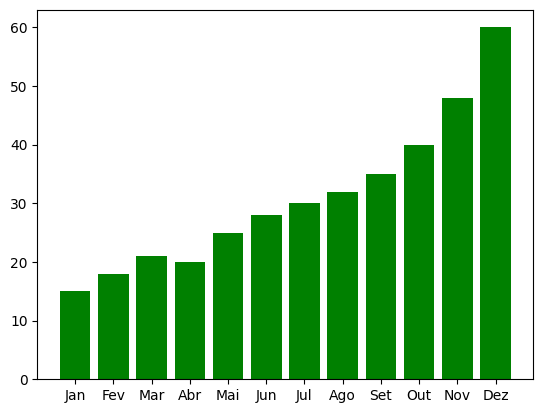

In [ ]:
plt.bar(df["Mes"], df["Vendas"], color = "g") # g = green(verde)
plt.show()

#### Horizontais
 A função utilizada aqui é a `barh()`

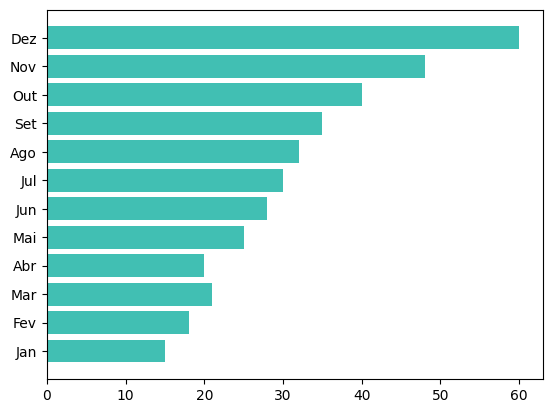

In [ ]:

plt.barh(df['Mes'], df["Vendas"], color = "#41BFB3", height=0.8)
plt.show()                                           # muda a altura da barra

## Parte de um todo
Servem para visualizar a proporção, porcentagem ou composição de categorias individuais em relação a um total de 100%. Eles facilitam a comparação imediata do tamanho de cada fatia no contexto geral, destacando contribuições de mercado, orçamentos ou pesquisas.

In [ ]:
dados_preferencia_lanche = {
    "Lanche": ["Pizza de Pepperoni", "Hambúrguer Vegano", "Sushi Combo", "Salada Caesar", "Tacos"],
    "Pedidos": [45, 30, 15, 7, 3],  # Total = 100 pedidos (facilita ver a %)
    "Cor_Hex": ["#F24405", "#558C03", "#F29F05", "#F2B705", "#730202"]
}



### Pizza
O gráfico de pizza (ou gráfico de setores) é mostrar a proporção de partes em relação a um todo. Ele é ideal para visualizar a composição de um conjunto de dados onde a soma de todas as fatias representa 100%.

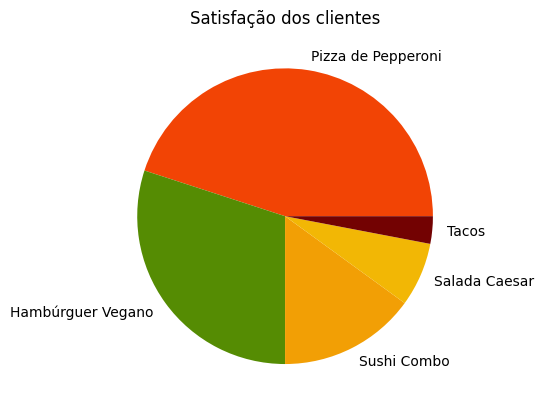

In [ ]:
#Código para separar a satisfacao em categorias
df = pd.DataFrame(dados_preferencia_lanche)
mylabels = df["Lanche"] # Nome das categorias
mycolors = df["Cor_Hex"] # Cor de cada parte do gráfico em hexa decimal
plt.title("Satisfação dos clientes")
plt.pie(df["Pedidos"], labels= mylabels, colors=mycolors)
plt.show()

### Rosquinha
Tanto a visualização de rosquinha e a de pizza, permitem visualizar a proporção em relação ao todo. O de rosquinha serve para adicionar informações adicionais, como um total geral ou um icone.

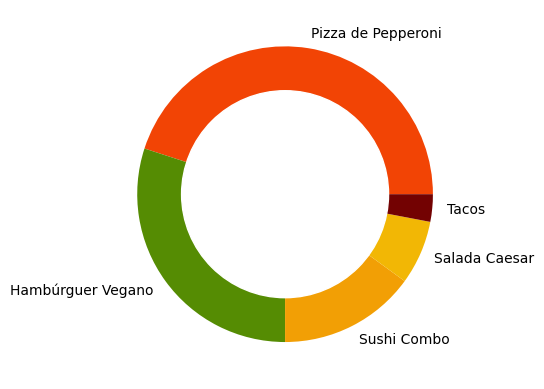

In [ ]:
plt.pie(df["Pedidos"], labels= mylabels, colors=mycolors)
# Adiciona um circulo no meio do gráfico de pizza
my_circle=plt.Circle( (0,0), 0.7, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

plt.show()

## Evolução
Servem para visualizar de forma clara e rápida mudanças, tendências, padrões de crescimento ou declínio de uma variável ao longo do tempo. Eles transformam dados numéricos brutos em insights visuais, facilitando a identificação de picos, quedas e a previsão de cenários futuros, sendo cruciais para a tomada de decisão

### Linha
Através de sequência de dado ligados, a visualização rápida de tendências, padrões e evolução de um mesmo tipo de dados é possível. Usando a biblioteca matplotlib e com a ajuda do pandas, é possível criar-los de maneira rápida e com uma quantidade de opões de personalização grandes.

In [ ]:
plt.plot(df['Mes'], df['Vendas']) # A função plot() gera um gráfico de linha
plt.grid() # adiciona grades ao fundo
plt.title("Desempenho de vendas por mês") # Título
plt.xlabel("Meses do ano") # Legenda no eixo x
plt.ylabel("Vendas") # Legenda no eixo y
plt.show() # Mostra os dados


KeyError: 'Mes'

## Diagrama de Sankey
A Sankey Diagramé uma técnica de visualização que permite exibir fluxos. Várias entidades ( nodes) são representadas por retângulos ou texto. Suas conexões são representadas por setas ou arcos que têm uma largura proporcional à importância do fluxo.

Para programarmos a visualização desse diagrama, precisamos de um pouco mais de atenção, pois no primeiro contato ele pode parecer complexo.
O primeiro passo para entendermos é a função `Figure()` do **graph_objects**, essa é uma função para criar imagens em uma visualização dados. Alguns dos parâmetros do exemplo abaixo são:

- `data`: nos diz que haverá uma imagem
- `go.Sankey`: informa que a imagem é um diagrama sankey
- `node`: uma função para as informações sobre os nós
  - `pad`: espaçamento entre nós
  - `thickness`: grossura dos nós
  - `line `: linha ao redor do nó
    - `color`: a cor da linha
    - `width`: grossura da linha
  - `label`: O nome de cada um dos nós
  - `color`: cor do nós
  - `link`: se refere as ligações entre os nós
    - `source`: os nós de origem
    - `target`: nós de destino
    - `value`: a intensidade, que implica na grossura do fluxo




In [ ]:
# import plotly.graph_objects as go

# fig = go.Figure(data=[go.Sankey(
#     node = dict(
#       pad = 15,
#       thickness = 20,
#       line = dict(color = "black", width = 0.5),
#       label = ["A1", "A2", "B1", "B2", "C1", "C2"],
#       color = "blue"
#     ),
#     link = dict(
#       source = [0, 1, 0, 2, 3, 3], # indices correspond to labels, eg A1, A2, A1, B1, ...
#       target = [2, 3, 3, 4, 4, 5],
#       value = [8, 4, 2, 8, 4, 2]
#   ))])

# fig.update_layout(title_text="Basic Sankey Diagram", font_size=10)
# fig.show()

url = "https://raw.githubusercontent.com/holtzy/data_to_viz/master/Example_dataset/13_AdjacencyDirectedWeighted.csv"
df = pd.read_csv(url)
df

,"Africa ""East Asia"" ""Europe"" ""Latin America"" ""North America"" ""Oceania"" ""South Asia"" ""South East Asia"" ""Soviet Union"" ""West Asia"""
0,Africa 3.142471 0 2.107883 0 0.540887 0.155988...
1,East Asia 0 1.630997 0.601265 0 0.97306 0.3336...
2,Europe 0 0 2.401476 0 0 0 0 0 0 0
3,Latin America 0 0 1.762587 0.879198 3.627847 0...
4,North America 0 0 1.215929 0.276908 0 0 0 0 0 0
5,Oceania 0 0 0.17037 0 0 0.190706 0 0 0 0
6,South Asia 0 0.525881 1.390272 0 1.508008 0.34...
7,South East Asia 0 0.145264 0.468762 0 1.057904...
8,Soviet Union 0 0 0.60923 0 0 0 0 0 1.870501 0
9,West Asia 0 0 0.449623 0 0.169274 0 0 0 0 0.92...


# Mapas

In [ ]:
import geopandas as gpd
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties
!pip install highlight_text
!pip install geoplot
!pip install geopandas
!pip install cartopy
from highlight_text import fig_text, ax_text
from matplotlib.patches import FancyArrowPatch

# geospatial manipulation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geoplot
import geoplot.crs as gcrs

In [ ]:
proj = ccrs.Mercator()

url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/all_world.geojson"
world = gpd.read_file(url)
world = world[~world['name'].isin(["Antarctica", "Greenland"])]
world = world.to_crs(proj.proj4_init)
world.head()

In [ ]:
url = "https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/earthquakes.csv"
df = pd.read_csv(url)

# Filter dataset: big earth quakes only
df = df[df['Depth (km)']>=0.01] # depth of at least 10 meters

# Sort: big bubbles must be below small bubbles for visibility
df.sort_values(by='Depth (km)', ascending=False, inplace=True)

df.head()

In [ ]:
proj = ccrs.Mercator()
fig, ax = plt.subplots(figsize=(12, 8), dpi=300, subplot_kw={'projection':proj})
ax.set_axis_off()

# background map
world.boundary.plot(ax=ax)

plt.show()

# Boas práticas
- **Manutenção da Simplicidade:** Evitar poluição visual e elementos desnecessários que dificultem a interpretação.
- **Clareza Informativa:** Sempre incluir títulos, rótulos de eixos e legendas explicativas.
- **Acessibilidade:** Projetar gráficos que sejam compreensíveis tanto para técnicos quanto para gestores e públicos leigos.
- **Escolha Estratégica:** Selecionar o tipo de gráfico com base no tipo de dado, nível de interatividade e público-alvo.